In [7]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

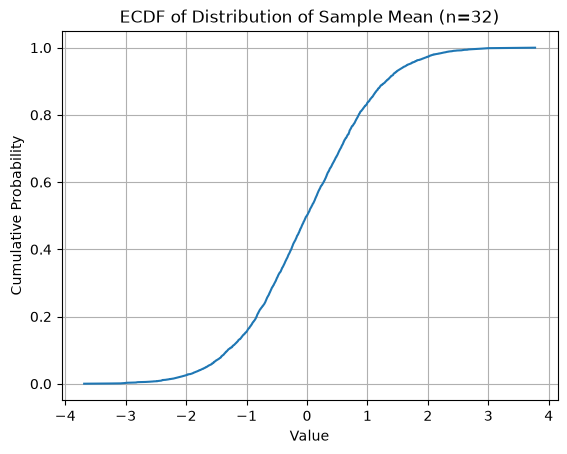

In [3]:
n = 32
b = 5000
values = []

for _ in range(b):
    draws = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    sample_mean = np.mean(draws)
    value = np.sqrt(n) * sample_mean
    values.append(value)

ecdf = ECDF(values)

plt.plot(ecdf.x, ecdf.y, label='Simulated ECDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Distribution of Sample Mean (n=32)')
plt.grid(True)
plt.show()

The curve follows a normal distribution's CDF, having the classic S-shape and is centered at 0. The rescaled sample means converge to a Normal distribution as n grows.

**Q5.**

We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for
understanding extreme events: We might be interested in the behavior of the biggest storm or earthquake
each year, but be working with a dataset about storms in general over 25 or 50 years.
1. Draw K=20 values from Uniform[0, 1].
2. Sort them by size from smallest to largest.
3. Record the largest value.
4. Repeat n times and plot the ECDF.
5. Repeat the previous steps for each rank from 1 to K.
6. What distribution(s) does this process generate? How does the distribution depend on the rank?

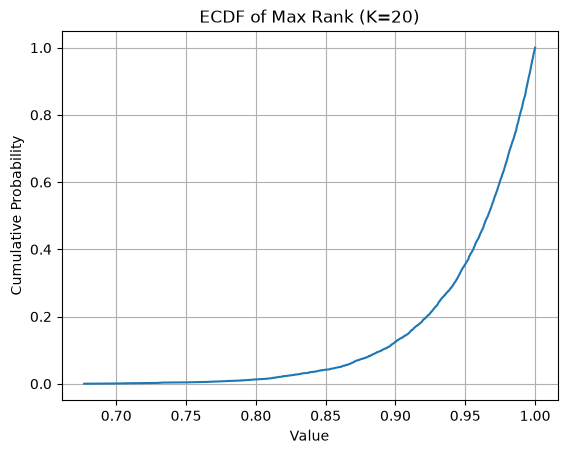

In [4]:
K = 20
n = 5000
values = []

for _ in range(n):
    draws = np.random.rand(K)
    draws = np.sort(draws)
    value = draws[-1]
    values.append(value)

ecdf = ECDF(values)

plt.plot(ecdf.x, ecdf.y, label='Simulated ECDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Max Rank (K=20)')
plt.grid(True)
plt.show()

The ECDF follows a beta distribution since it's heavily skewed-left. If the rank was small it would be skewed-right and if it was towards the middle it would be more normally distributed


**Q8.**

Imagine a toy model of a collection of particles constantly colliding and exchanging energy, while the total amount of energy in the system remains fixed. No particle keeps its energy forever: repeated random exchanges eventually produce a stable distribution even though every individual particle continues to change.

1. Initialize `n = 1_000` particles with energy $E_i=1$.
2. Randomly choose two particles $i$ and $j$. Add their energies, $ E = E_i + E_j$ .
3. Draw a uniformly distributed number from between 0 and 1, $u$ and redistribute the energy: $ E_i = uE$ and $E_j=(1-u)E. $
4. Repeat this random exchange `b=1_000_000` times.
5. Record the final energies of all particles and plot their ECDF.
6. What distribution does this simulation approach as $n$ becomes large?
7. How does the distribution change if you increase or decrease the initial energy for each particle?

In [6]:
n = 1000
b = 1000000

particles = np.zeros(n) + 1

<Axes: xlabel='Particle Energy', ylabel='Proportion'>

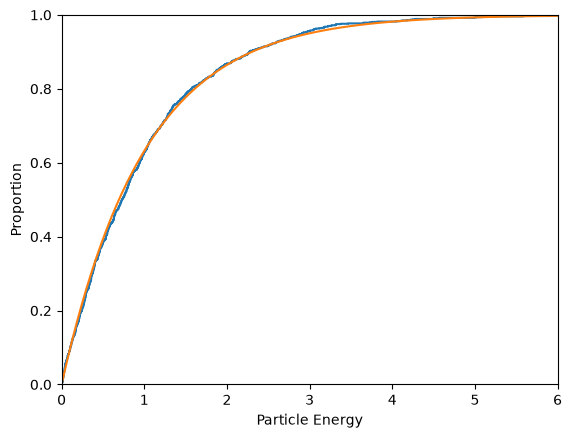

In [8]:
for _ in range(b):
    i = random.randint(0, n - 1)
    j = random.randint(0, n - 1)

    # Just make sure that i =/= j
    while i == j:
        j = random.randint(0, n - 1)

    E = particles[i] + particles[j]

    u = random.random()

    particles[i] = u * E
    particles[j] = (1 - u) * E

sns.ecdfplot(data=particles)
plt.xlabel('Particle Energy')
plt.xlim((0, 6))

# First order step response
x = np.linspace(0, 6, num=100)
y = 1 - np.exp(-x)
sns.lineplot(x=x, y=y)

The ECDF plot seems to have a similar shape to an inverse tangent curve, or a first order step response plot. Plotting a first order step response curve (1 - e^(-x)) over top of the ECDF shows a very good match to the experimental data, indicating that F(x) = 1 - e^-x.

Since f(x) = F'(x), we then know that the PDF is e^-x

Text(0.5, 0, 'Particle Energy')

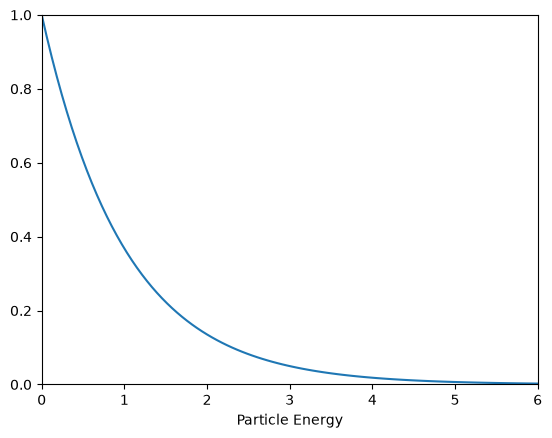

In [9]:
# Plot the PDF
x = np.linspace(0, 6, num=100)
y = np.exp(-x)
sns.lineplot(x=x, y=y)
plt.xlim((0, 6))
plt.ylim((0, 1))
plt.xlabel('Particle Energy')

(0.0, 60.0)

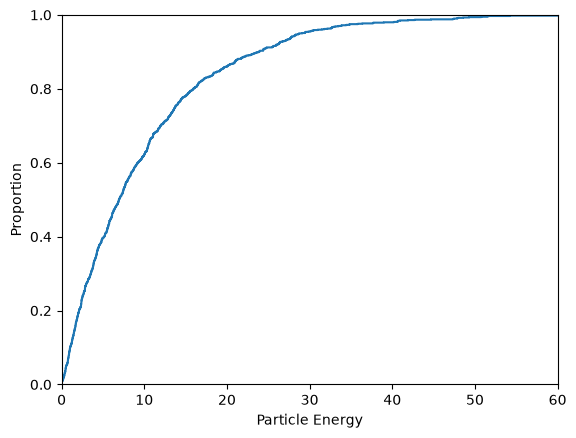

In [10]:
# Test different initial energies
particles = np.zeros(n) + 10

for _ in range(b):
    i = random.randint(0, n - 1)
    j = random.randint(0, n - 1)

    # Just make sure that i =/= j
    while i == j:
        j = random.randint(0, n - 1)

    E = particles[i] + particles[j]

    u = random.random()

    particles[i] = u * E
    particles[j] = (1 - u) * E

sns.ecdfplot(data=particles)
plt.xlabel('Particle Energy')
plt.xlim((0, 60))

Adjusting the initial energy simply stretches the ECDF plot horizontally. The underlying shape of the data is still the same. Larger initial energy -> the ECDF plot gets wider horizontally, and smaller initial energy -> the ECDF plot gets narrower horizontally.

### Google Usage
The resulting ECDF curve looked very similar to step response curves I learned about in my mechanical engineering undergrad. I didn't remember the exact formula for a first order step response curve, so I googled the equation and plugged it in to the plot above and it fit very well.